In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

RAW_DIR = Path('../data/raw')

MODEL_FEATURES = {
    'logistic_regression': ['time_remaining', 'pct_change_binance', 'pct_change_coinbase', 'pct_change_kraken'],
    'lightgbm':            ['time_remaining', 'pct_change_binance', 'pct_change_coinbase', 'pct_change_kraken'],
    'xgboost':             ['time_remaining', 'pct_change_binance', 'pct_change_coinbase', 'pct_change_kraken'],
}

CANDLE_INTERVAL_S = 300

In [2]:
def pct_change_series(s):
    filled = s.ffill()
    first = filled.dropna()
    if first.empty or float(first.iloc[0]) == 0:
        return pd.Series(np.nan, index=s.index)
    open_price = float(first.iloc[0])
    return filled.apply(lambda v: (float(v) - open_price) / open_price if pd.notna(v) else np.nan)

def load_candle(f):
    df = pd.read_parquet(f).sort_values('datetime').reset_index(drop=True)
    if df.empty:
        return None
    t_start = pd.Timestamp(df['datetime'].iloc[0])
    df['time_remaining'] = df['datetime'].apply(
        lambda ts: max(0, int(CANDLE_INTERVAL_S - (pd.Timestamp(ts) - t_start).total_seconds()))
    )
    df['pct_change_binance']  = pct_change_series(df['btc_usd'])
    df['pct_change_coinbase'] = pct_change_series(df['btc_coinbase']) if 'btc_coinbase' in df.columns else np.nan
    df['pct_change_kraken']   = pct_change_series(df['btc_kraken'])   if 'btc_kraken'   in df.columns else np.nan
    df['file'] = f.name
    return df

files = sorted(RAW_DIR.glob('ticks_*.parquet'))
print(f'{len(files)} parquet files found')

frames = []
for f in files:
    try:
        c = load_candle(f)
        if c is not None:
            frames.append(c)
    except Exception as e:
        print(f'  SKIP {f.name}: {e}')

raw = pd.concat(frames, ignore_index=True)
print(f'{len(raw):,} total rows across {len(frames)} candles')

854 parquet files found


  SKIP ticks_0x6d8087d439d1eba4deae0a50fc150e77e3fd93d7dba9be7a1972c932c22052df_20260525_155243.parquet: Could not open Parquet input source '<Buffer>': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.


247,821 total rows across 853 candles


In [3]:
# Non-null counts per relevant column
cols = ['yes_price', 'no_price', 'btc_usd', 'btc_coinbase', 'btc_kraken',
        'pct_change_binance', 'pct_change_coinbase', 'pct_change_kraken', 'time_remaining']
present = [c for c in cols if c in raw.columns]

summary = pd.DataFrame({
    'non_null': raw[present].notna().sum(),
    'null':     raw[present].isna().sum(),
})
summary['total'] = len(raw)
summary['pct_valid'] = (100 * summary['non_null'] / summary['total']).round(1)
summary

,non_null,null,total,pct_valid
yes_price,245944,1877,247821,99.2
no_price,245944,1877,247821,99.2
btc_usd,247796,25,247821,100.0
btc_coinbase,3007,244814,247821,1.2
btc_kraken,3000,244821,247821,1.2
pct_change_binance,247796,25,247821,100.0
pct_change_coinbase,3007,244814,247821,1.2
pct_change_kraken,3000,244821,247821,1.2
time_remaining,247821,0,247821,100.0


In [4]:
# Valid rows per model (all features non-null)
print(f'Total rows: {len(raw):,}')
print()
for model_id, features in MODEL_FEATURES.items():
    available = [f for f in features if f in raw.columns]
    missing_cols = [f for f in features if f not in raw.columns]
    valid = raw[available].notna().all(axis=1).sum()
    pct = 100 * valid / len(raw)
    note = f'  (missing columns: {missing_cols})' if missing_cols else ''
    print(f'{model_id:25s}  valid={valid:>8,}  ({pct:.1f}%){note}')

Total rows: 247,821

logistic_regression        valid=   2,999  (1.2%)
lightgbm                   valid=   2,999  (1.2%)
xgboost                    valid=   2,999  (1.2%)


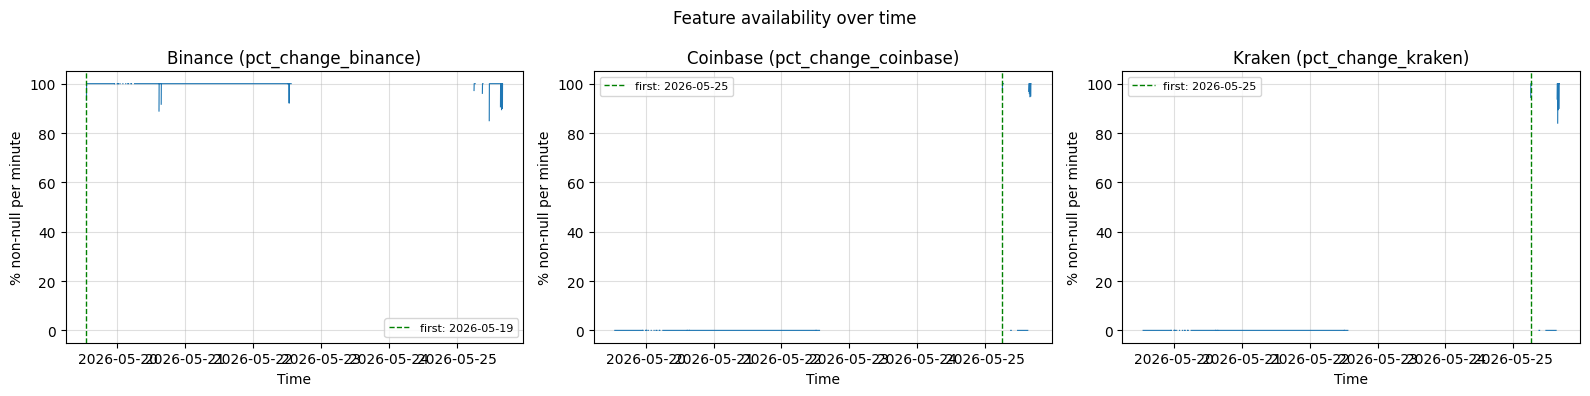

In [5]:
# Timeline: when did each exchange column become available?
raw['datetime'] = pd.to_datetime(raw['datetime'], utc=True)
raw_sorted = raw.sort_values('datetime')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, label in [
    (axes[0], 'pct_change_binance',  'Binance (pct_change_binance)'),
    (axes[1], 'pct_change_coinbase', 'Coinbase (pct_change_coinbase)'),
    (axes[2], 'pct_change_kraken',   'Kraken (pct_change_kraken)'),
]:
    if col not in raw_sorted.columns:
        ax.set_title(f'{label}\n(column absent)')
        continue
    # rolling 1-min availability
    by_minute = raw_sorted.set_index('datetime')[col].notna().resample('1min').mean()
    ax.plot(by_minute.index, by_minute.values * 100, linewidth=0.8)
    ax.set_title(label)
    ax.set_ylabel('% non-null per minute')
    ax.set_xlabel('Time')
    ax.set_ylim(-5, 105)
    first_valid = by_minute[by_minute > 0].index.min()
    if pd.notna(first_valid):
        ax.axvline(first_valid, color='green', linewidth=1, linestyle='--', label=f'first: {first_valid.date()}')
        ax.legend(fontsize=8)

plt.suptitle('Feature availability over time', fontsize=12)
plt.tight_layout()
plt.show()

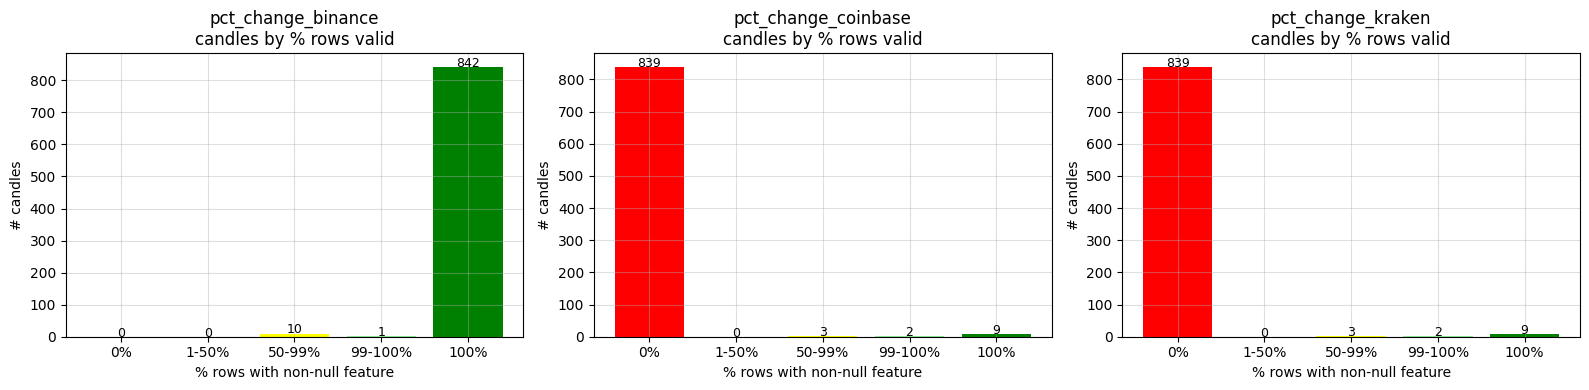


Candles with 100% valid pct_change_binance:  842
Candles with 100% valid pct_change_coinbase: 9
Candles with 100% valid pct_change_kraken:   9


In [6]:
# Break down valid rows by candle (file) — are any candles entirely missing a feature?
candle_stats = []
for f_name, grp in raw.groupby('file'):
    row = {'file': f_name, 'rows': len(grp)}
    for col in ['pct_change_binance', 'pct_change_coinbase', 'pct_change_kraken']:
        if col in grp.columns:
            row[f'{col}_valid'] = grp[col].notna().sum()
            row[f'{col}_pct']   = round(100 * grp[col].notna().mean(), 1)
        else:
            row[f'{col}_valid'] = 0
            row[f'{col}_pct']   = 0.0
    candle_stats.append(row)

cs = pd.DataFrame(candle_stats)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in [
    (axes[0], 'pct_change_binance'),
    (axes[1], 'pct_change_coinbase'),
    (axes[2], 'pct_change_kraken'),
]:
    pct_col = f'{col}_pct'
    if pct_col not in cs.columns:
        continue
    buckets = [0, 1, 50, 99, 100, 101]
    labels  = ['0%', '1-50%', '50-99%', '99-100%', '100%']
    counts = pd.cut(cs[pct_col], bins=buckets, labels=labels, right=False, include_lowest=True).value_counts().reindex(labels, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=['red','orange','yellow','lightgreen','green'])
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(v), ha='center', fontsize=9)
    ax.set_title(f'{col}\ncandles by % rows valid')
    ax.set_xlabel('% rows with non-null feature')
    ax.set_ylabel('# candles')

plt.tight_layout()
plt.show()

print(f'\nCandles with 100% valid pct_change_binance:  {(cs["pct_change_binance_pct"] == 100).sum()}')
print(f'Candles with 100% valid pct_change_coinbase: {(cs["pct_change_coinbase_pct"] == 100).sum()}')
print(f'Candles with 100% valid pct_change_kraken:   {(cs["pct_change_kraken_pct"] == 100).sum()}')

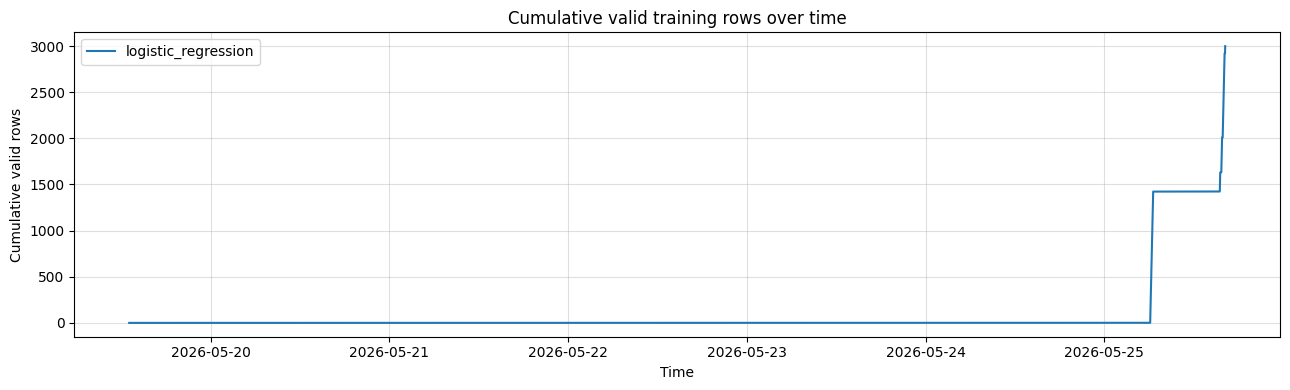

In [7]:
# Cumulative valid training rows over time for each model
all_features = sorted({f for feats in MODEL_FEATURES.values() for f in feats})
raw2 = raw.sort_values('datetime').copy()

fig, ax = plt.subplots(figsize=(13, 4))
plotted = set()
for model_id, features in MODEL_FEATURES.items():
    key = tuple(sorted(features))
    if key in plotted:
        continue
    plotted.add(key)
    available = [f for f in features if f in raw2.columns]
    valid_mask = raw2[available].notna().all(axis=1)
    cumulative = valid_mask.cumsum()
    ax.plot(raw2['datetime'], cumulative, label=model_id)

ax.set_title('Cumulative valid training rows over time')
ax.set_xlabel('Time')
ax.set_ylabel('Cumulative valid rows')
ax.legend()
plt.tight_layout()
plt.show()